In [1]:
!python3 -m pip install matplotlib google-cloud-bigquery pandas


[notice] A new release of pip is available: 23.3.1 -> 23.3.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from google.cloud import bigquery
import pandas as pd


bq_client = bigquery.Client(project="ld-ds-genai-dev")

In [3]:
fixture_query_path = "process_floor_plan/queries/fixtures.sql"
store_id = "1011"


fixture_query  = f"""
WITH
  floor_plan AS (
  SELECT
    DBVERSIONKEY AS floor_plan_key,
    VALUE1 AS store_id,
  FROM
    `ds-bi-analytics-prod.JDA.JDA_IX_FLR_FLOORPLAN`
  WHERE
    VALUE1 = "{store_id}"
    AND DELETED_FLAG = FALSE
    AND STATUS1 = "Live"
    AND DBVERSIONKEY in (select DBPARENTFLOORPLANKEY from `ds-bi-analytics-prod.JDA.JDA_IX_FLR_FIXTURE`)
  ORDER BY
    timestamp DESC
  LIMIT
    1 ),
  fixture AS (
  SELECT
    floor_plan_key,
    store_id,
    SAFE_CAST(ANGLE AS INT64) AS ANGLE,
    SAFE_CAST(WIDTH AS INT64) AS WIDTH,
    SAFE_CAST(DEPTH AS INT64) AS DEPTH,
    SAFE_CAST(HEIGHT AS INT64) AS HEIGHT,
    SAFE_CAST(X AS FLOAT64) AS X,
    SAFE_CAST(Y AS FLOAT64) AS Y,
    SAFE_CAST(Z AS FLOAT64) AS Z,
    DESC5 AS AISLE,
    DESC9 AS PCX_LOCATION,
    TYPE AS FIXTURE_TYPE,
  FROM
    floor_plan
  LEFT JOIN
    `ds-bi-analytics-prod.JDA.JDA_IX_FLR_FIXTURE` fixt
  ON
    fixt.DBPARENTFLOORPLANKEY = floor_plan.floor_plan_key
  WHERE
    DELETED_FLAG = FALSE
  AND
    TYPE in ("0", "1")) -- type 0 is for regular fixtures, and type 1 for irregular ones

SELECT
  floor_plan_key,
  store_id,
  X AS STARTING_X,
  case
    when fixture.ANGLE in (270,90) then COS(-1*fixture.Angle*0.01745329251)*fixture.WIDTH + SIN(-1*fixture.Angle*0.01745329251)*fixture.DEPTH +fixture.X
    else COS(fixture.Angle*0.01745329251)*fixture.WIDTH + SIN(fixture.Angle*0.01745329251)*fixture.DEPTH + fixture.X
  end AS ENDING_X,
  Y AS STARTING_Y,
  (SIN(fixture.Angle*0.01745329251)*fixture.WIDTH + COS(fixture.Angle*0.01745329251)*fixture.DEPTH + fixture.Y) AS ENDING_Y,
  Z,
  WIDTH,
  DEPTH,
  HEIGHT,
  ANGLE,
  AISLE,
  PCX_LOCATION,
  FIXTURE_TYPE,
FROM
  fixture
"""
fixtures_df = bq_client.query(fixture_query).to_dataframe()

fixtures_df

,floor_plan_key,store_id,STARTING_X,ENDING_X,STARTING_Y,ENDING_Y,Z,WIDTH,DEPTH,HEIGHT,ANGLE,AISLE,PCX_LOCATION,FIXTURE_TYPE
0,208376,1011,2299.746094,2318.746094,1992.000122,1963.000122,0.2,29,19,2,270,JO01C,None,0
1,208376,1011,568.863276,580.863276,1669.155640,1621.155640,0.2,48,12,2,270,DL01L,None,0
2,208376,1011,592.863276,580.863276,2029.405762,2077.405762,0.2,48,12,2,90,DL01L,None,0
3,208376,1011,568.863276,580.863276,2077.405762,2029.405762,0.2,48,12,2,270,DL01L,None,0
4,208376,1011,592.863276,580.863276,1981.405762,2029.405762,0.2,48,12,2,90,DL01L,None,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1608,208376,1011,2818.020020,2787.020020,2100.650391,2148.650391,0.2,48,31,2,90,GR03L,None,0
1609,208376,1011,2818.020020,2787.020020,2532.650391,2580.650391,0.2,48,31,2,90,GR03L,None,0
1610,208376,1011,2818.020020,2787.020020,1476.650391,1524.650391,0.2,48,31,2,90,GR03L,None,0
1611,208376,1011,2818.020020,2787.020020,2292.650391,2340.650391,0.2,48,31,2,90,GR03L,None,0


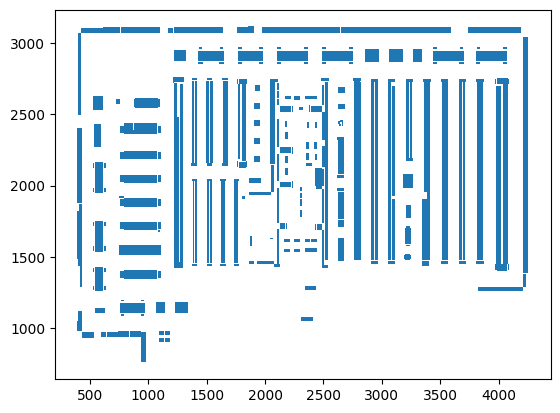

In [4]:
fig, ax = plt.subplots()
ax.plot()
for x, y, x1, y1 in zip(fixtures_df["STARTING_X"], fixtures_df["STARTING_Y"], fixtures_df["ENDING_X"], fixtures_df["ENDING_Y"]):
    ax.add_patch(Rectangle((x, y), float(x1-x), float(y1-y)))

plt.show()

In [17]:
item_fixture_query  = f"""
SELECT
  liam,
  name_en,
  nav_categories_en,
  STARTING_X_FT*12 AS X1,
  STARTING_Y_FT*12 AS Y1
FROM
  `ds-bi-analytics-prod.JDA.JDA_ITEM_LOCATION` jda
JOIN (
  SELECT
    liam, name_en, STRING_AGG(cat.en, ", ") AS nav_categories_en
  FROM
    `ds-bi-analytics-prod.product_catalog.products`
  LEFT JOIN
    UNNEST(nav_categories) AS cat
  WHERE
    status="APPROVED"
  GROUP BY liam, name_en)pcs
ON
  jda.ARTICLE_ID_UOM = pcs.liam
WHERE
  STORE_ID = "{store_id}"
"""
item_fixtures_df = bq_client.query(item_fixture_query).to_dataframe()
item_fixtures_df = item_fixtures_df[item_fixtures_df["nav_categories_en"].notna()].reset_index(drop=True)
item_fixtures_df["nav_categories_en"] = item_fixtures_df["nav_categories_en"].str.lower()
item_fixtures_df["nav_categories_en"] = item_fixtures_df["nav_categories_en"].str.split(", ")

item_fixtures_df

,liam,name_en,nav_categories_en,X1,Y1
0,21157593_KG,Original Cheese,"[food, deli, deli cheese, brie, camembert & wa...",435.840000000,1874.760000000
1,20987454_C06,Naturally Alkaline Spring Water,None,2052.720000000,2145.240000000
2,20962530_EA,"Long Life Alkaline Batteries, Aaa","[household supplies, batteries, batteries & el...",2756.520000000,2750.520000000
3,20962530_EA,"Long Life Alkaline Batteries, Aaa","[household supplies, batteries, batteries & el...",2756.520000000,2750.520000000
4,21476744_EA,Taco Bites,"[food, frozen, appetizers & snacks, hors d’oeu...",2618.640000000,2874.480000000
...,...,...,...,...,...
31462,21243208_EA,"Popcorn Shrimp, Tail-Off Shrimp, Breaded with ...","[food, frozen, frozen meat & seafood, frozen f...",4210.800000000,2469.000000000
31463,21363913_EA,Hong Kong Style Bbq Flavor Bun,"[food, frozen, meals, entrees & sides, meals, ...",4210.800000000,1959.000000000
31464,21236984_EA,Momenti Tomato & Mozzarella Pizza,"[food, frozen, frozen pizza]",4210.800000000,2589.000000000
31465,20296100002_EA,Ristorante Thin Crust Mozzarella Pizza,"[food, frozen, frozen pizza]",4210.800000000,3039.000000000


In [18]:
item_fixtures_df[item_fixtures_df["liam"].str.contains("KG")]

,liam,name_en,nav_categories_en,X1,Y1
0,21157593_KG,Original Cheese,"[food, deli, deli cheese, brie, camembert & wa...",435.840000000,1874.760000000
12,21563519_KG,Chocolate Flavored Macaroons,"[food, pantry, bulk nuts and candy]",1082.880000000,2613.360000000
15,21563420_KG,Sour Ju Jubes Candy,"[food, pantry, bulk nuts and candy]",1082.880000000,2613.360000000
18,21564171_KG,Strawberry Lime Rings,"[food, pantry, bulk nuts and candy]",1082.880000000,2613.360000000
22,20821154_KG,"Free From Chicken Thigh, Boneless, Skinless, C...","[food, meat, chicken & turkey, chicken legs,th...",2404.920000000,3069.600000000
...,...,...,...,...,...
4336,20377023_KG,Parmigiano Reggiano,"[food, deli, deli cheese, parmesan & hard cheese]",616.920000000,2161.440000000
4339,20102179_KG,Asiago Cheese,"[food, deli, deli cheese, parmesan & hard cheese]",616.920000000,2161.440000000
4355,20434575_KG,Parmigiano Reggiano,"[food, deli, deli cheese, parmesan & hard cheese]",616.920000000,2161.440000000
4358,20632822_KG,Asiago,"[food, deli, deli cheese, parmesan & hard cheese]",616.920000000,2161.440000000


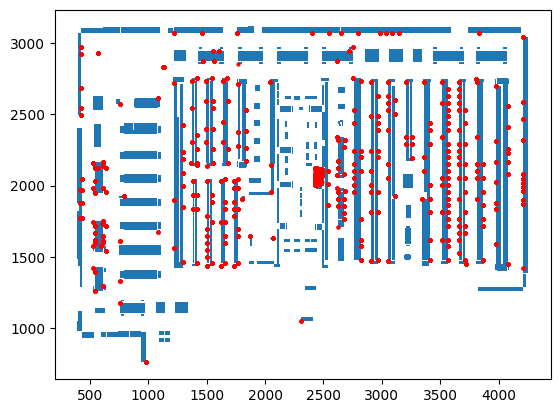

In [19]:
fig, ax = plt.subplots()
ax.plot()
for x, y, x1, y1 in zip(fixtures_df["STARTING_X"], fixtures_df["STARTING_Y"], fixtures_df["ENDING_X"], fixtures_df["ENDING_Y"]):
    ax.add_patch(Rectangle((x, y), float(x1-x), float(y1-y)))

plt.plot(item_fixtures_df["X1"], item_fixtures_df["Y1"], 'o', markersize=2, color='#ff0000')

plt.show()

In [34]:
level_2_categories = item_fixtures_df["nav_categories_en"].apply(lambda x: x[1]).value_counts()
level_2_categories

nav_categories_en
pantry                                 4871
personal care                          3907
natural and organic                    2722
snacks                                 2064
drinks                                 2040
                                       ... 
electrical supplies                       2
home & kitchen                            2
fasteners                                 1
scrapbooking                              1
painting supplies & wall treatments       1
Name: count, Length: 71, dtype: int64

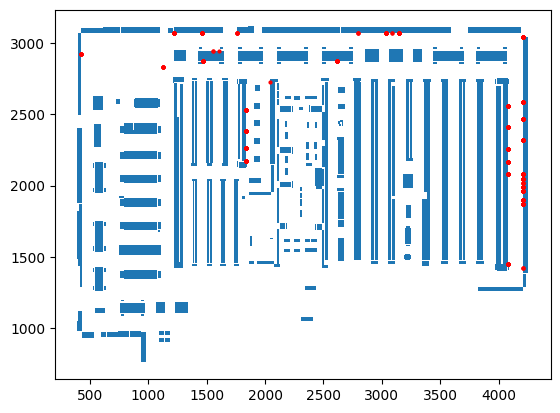

In [35]:
# Here I plot all frozen items, try plotting all items with different colors based on their second level category
item_fixtures_subset = item_fixtures_df[item_fixtures_df["nav_categories_en"].apply(lambda x: x[1] == "frozen")]

fig, ax = plt.subplots()
ax.plot()
for x, y, x1, y1 in zip(fixtures_df["STARTING_X"], fixtures_df["STARTING_Y"], fixtures_df["ENDING_X"], fixtures_df["ENDING_Y"]):
    ax.add_patch(Rectangle((x, y), float(x1-x), float(y1-y)))

plt.plot(item_fixtures_subset["X1"], item_fixtures_subset["Y1"], 'o', markersize=2, color='#ff0000')

plt.show()

In [39]:
# Lets drill into the product metadata contained within PCS

pcs_query = """
SELECT
    pcs.article_number AS product_article_number,
    liam AS product_id,
    TRIM(brand.name_en) AS brand_en,
    TRIM(brand.sub_brand.name_en) AS sub_brand_en,
    TRIM(name_en) AS title_en,
    TRIM(REGEXP_REPLACE(description_en, r'(<\/?[a-z]+>)+', '')) AS description_en,
    STRING_AGG(cat.en, ", ") AS nav_categories_en
FROM
    `ds-bi-analytics-prod.product_catalog.products` pcs
LEFT JOIN
    UNNEST(nav_categories) AS cat
WHERE
    status = 'APPROVED'
    AND NOT SUBSTRING(liam, 0, 2) = 'DD'
GROUP BY
    pcs.article_number,
    liam,
    name_en,
    description_en,
    brand.name_en,
    brand.sub_brand.name_en
"""
pcs_df = bq_client.query(pcs_query).to_dataframe()
pcs_df

,product_article_number,product_id,brand_en,sub_brand_en,title_en,description_en,nav_categories_en
0,20594766002,20594766002_EA,Nong Shim,BOWL NOODLE,"Bowl Noodle Soup, Beef Flavour",None,"Food, Pantry, Easy Meals & Sides, Dry Soup Mix..."
1,20984270,20984270_EA,GlutenFreeda,None,"Instant Oatmeal, Banana Maple With Flax",Have a Delicious Day!.Our Instant Oatmeal will...,"Food, Natural and Organic, Breakfast, Cereal, ..."
2,038097020151,SDM_038097020151,Tweezerman,None,Midnight Cheers Brow & Lash Set,Celebrate the holidays with this Special Editi...,"Beauty, Tools & Accessories, Makeup Brushes & ..."
3,20376950,20376950_EA,ACADIAN MAPLE,None,Acadian Maple Products Nova Scotia Wild Bluebe...,None,"Food, Pantry, Honey, Syrups & Spreads, Maple S..."
4,20974246,20974246_EA,Unique,None,9oz Finding Dory Cups,None,"Toys, Games & Party Supplies, Party Supplies, ..."
...,...,...,...,...,...,...,...
427094,20739399,20739399_EA,Everyday Essentials,None,Peeler,Stainless steel blade.Comfort-grip handle.Dish...,"Home & Kitchen, Kitchen, Kitchen Utensils, Gad..."
427095,20754583,20754583_EA,Everyday Essentials,None,"Plastic Glide Hooks, White",None,"Home & Kitchen, Bath, Bathtub & Shower Accesso..."
427096,20867000,20867000_EA,Everyday Essentials,None,Owl Creamer & Sugar Holders,None,"Home & Kitchen, Dining & Entertaining, Servewa..."
427097,20921958,20921958_EA,Everyday Essentials,None,Mini Silicone Tongs,None,"Home & Kitchen, Kitchen, Kitchen Utensils, Gad..."


In [40]:
# Some products are missing brand, descriptions, categories
display(pcs_df[pcs_df["brand_en"].isna()])
display(pcs_df[pcs_df["title_en"].isna()])
display(pcs_df[pcs_df["description_en"].isna()])
display(pcs_df[pcs_df["nav_categories_en"].isna()])

,product_article_number,product_id,brand_en,sub_brand_en,title_en,description_en,nav_categories_en
608,20162728001,20162728001_EA,None,None,Baking Potatoes,Baking (or russet) potatoes have a rough brown...,None
837,3264680005374,SDM_3264680005374,None,None,Crème Fraichede Beauté Masque\n24hr Soothing a...,A source of well-being and immediate freshness...,None
1129,20545752,20545752_EA,None,None,Wind Resistant BBQ lighter,None,None
1151,20060060,20060060_EA,None,None,Atemoya,Atemoya is a fruit with bumpy green skin and c...,None
1178,20381176,20381176_EA,None,None,Black Label Équateur Origine Dark Chocolate Co...,"With 72% cocoa, our bold dark chocolate couver...",None
...,...,...,...,...,...,...,...
214573,20319740002,20319740002_C12,None,None,Lactose Free A+ Concentrated Formula (Case),None,None
214643,3349668600298,SDM_3349668600298,None,None,1 Million Elixir Parfum Intense,Paco Rabanne 1 Million Elixir: the pinnacle of...,"Beauty, Men's, Fragrance for Him, Cologne, Bea..."
214717,20628759001,20628759001_EA,None,None,"Cereal, Rice & Baa",None,None
214805,20300190,20300190_KG,None,None,"Lean Ground Beef, Tray Pack",None,None


,product_article_number,product_id,brand_en,sub_brand_en,title_en,description_en,nav_categories_en
32379,BB,SDM_BB_5060663680112,None,None,None,None,None
73232,BB,SDM_BB_5060663680099,None,None,None,None,None


,product_article_number,product_id,brand_en,sub_brand_en,title_en,description_en,nav_categories_en
0,20594766002,20594766002_EA,Nong Shim,BOWL NOODLE,"Bowl Noodle Soup, Beef Flavour",None,"Food, Pantry, Easy Meals & Sides, Dry Soup Mix..."
3,20376950,20376950_EA,ACADIAN MAPLE,None,Acadian Maple Products Nova Scotia Wild Bluebe...,None,"Food, Pantry, Honey, Syrups & Spreads, Maple S..."
4,20974246,20974246_EA,Unique,None,9oz Finding Dory Cups,None,"Toys, Games & Party Supplies, Party Supplies, ..."
9,884392597542,SDM_884392597542,Safety 1St,None,Grow With Me Medicine Set,None,"Baby & Child, Baby & Child Care, Childproofing..."
10,21185534,21185534_EA,Voortman,None,Mango Wafer Cookies,None,"Food, Snacks, Chips & Candy, Crackers & Cookie..."
...,...,...,...,...,...,...,...
427090,20839688,20839688_EA,Everyday Essentials,None,"Microfibre Drying Mat, Printed",None,"Home & Kitchen, Dining & Entertaining, Table L..."
427093,20869142,20869142_EA,Everyday Essentials,None,"Round Tin, Large",None,"Home & Kitchen, Dining & Entertaining, Servewa..."
427095,20754583,20754583_EA,Everyday Essentials,None,"Plastic Glide Hooks, White",None,"Home & Kitchen, Bath, Bathtub & Shower Accesso..."
427096,20867000,20867000_EA,Everyday Essentials,None,Owl Creamer & Sugar Holders,None,"Home & Kitchen, Dining & Entertaining, Servewa..."


,product_article_number,product_id,brand_en,sub_brand_en,title_en,description_en,nav_categories_en
12,3380814024513,SDM_3380814024513,Clarins,None,Everlasting Compact Foundation SPF 15,A high-performance foundation with an ultra-fi...,None
18,8411061962015,SDM_8411061962015,Carolina Herrera,None,Good Girl Glorious Gold Holiday Collector Eau ...,Good Girl Glorious Gold Holiday Collector Eau ...,None
25,21029278,21029278_EA,Papermate,FLAIR,"Flair! Felt Tip Pens, Limited Edition Candy Pop",None,None
63,21204508,21204508_C18,Reese's,None,Outrageous Candy,None,None
68,4020829078895,SDM_4020829078895,Dr.Hauschka,None,Dr H Starter Kit Cmbntion Skin,Discover Dr. Hauschka three-step skin care rit...,None
...,...,...,...,...,...,...,...
426935,20725817,20725817_EA,Everyday Essentials,None,"Clear Accessories Box, 2L",Includes snap-on lidStackableWipe with damp cloth,None
426956,21398035,21398035_EA,Everyday Essentials,None,15 Paper Cups - Summer Geo,350ml,None
426960,20759028,20759028_EA,Everyday Essentials,None,"Locker Storage, Large",None,None
427041,21414130,21414130_EA,Everyday Essentials,None,15 Paper Cups Flower,350ml,None


In [ ]:
# Some products that are missing descriptions have other metadata, lets use that along with ChatGPT to generate some product descriptions
from openai import OpenAI  # type: ignore
import os

openai_client = OpenAI(
    api_key=os.environ["OPENAI_API_KEY"],  # Request this key from your lead
)

input_prompt = "TODO"

response = openai_client.chat.completions.create(
    model="gpt-3.5-turbo",
    messages=[
        {"role": "user", "content": input_prompt},
    ],
)
text = response.choices[0].message.content